# Итоговый проект: анализ продаж и прибыльности сети магазинов Superstore

**Источник данных:** Sample Superstore Dataset, kaggle.com/datasets/vivek468/superstore-dataset-final
**Период:** 03.01.2014–30.12.2017

## Исследовательский вопрос

Какие категории и подкатегории товаров приносят наибольшую выручку, но при этом теряют прибыль
из-за скидок, и какие клиентские сегменты обеспечивают основную ценность бизнесу Superstore?

## Паспорт данных

**Источник данных:** Kaggle
**Период:** 03.01.2014–30.12.2017 (4 года)
**Ключевые поля:** `Order ID` (заказ), `Product ID` (товар), `Customer ID` (клиент)
**Основные признаки:** `Sales`, `Quantity`, `Discount`, `Profit` (числовые); `Segment`, `Category`,
  `Sub-Category`, `Region`, `State` (категориальные); `Order Date`, `Ship Date` (временные)
**Связи между таблицами:** одна таблица
**Ограничения:** нет данных о себестоимости отдельно от прибыли, поэтому анализ прибыльности опирается на уже готовое поле `Profit`

## План работы
1. Загрузка и проверка качества данных
2. Очистка и предобработка (ETL)
3. Исследовательский анализ данных (EDA)
4. ABC-анализ подкатегорий
5. XYZ-анализ подкатегорий
6. RFM-анализ клиентов
7. Ответ на исследовательский вопрос
8. Экспорт данных для BI-дашборда


## 0. Установка и импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)


## 1. Загрузка данных


In [5]:
filename = 'Sample - Superstore.csv'
df = pd.read_csv(filename, encoding='ISO-8859-1')
print(df.shape)
df.head()


(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 2. Проверка качества данных

In [18]:
print('Пропуски по полям:')
print(df.isna().sum())

Пропуски по полям:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [19]:
print('Полные дубликаты строк:', df.duplicated().sum())

Полные дубликаты строк: 0


In [20]:
print('Типы столбцов:')
print(df.dtypes)

Типы столбцов:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [4]:
# Допустимость значений
print('Отрицательные Sales:', (df['Sales'] < 0).sum())
print('Отрицательный Quantity:', (df['Quantity'] < 0).sum())
print('Discount вне диапазона [0,1]:', ((df['Discount'] < 0) | (df['Discount'] > 1)).sum())
print('Строк с отрицательной прибылью (Profit < 0):', (df['Profit'] < 0).sum(),
      f"({round((df['Profit']<0).mean()*100,1)}% от всех строк)")
print('Уникальных заказов:', df['Order ID'].nunique(), '| уникальных клиентов:', df['Customer ID'].nunique(),
      '| уникальных товаров:', df['Product ID'].nunique())


Отрицательные Sales: 0
Отрицательный Quantity: 0
Discount вне диапазона [0,1]: 0
Строк с отрицательной прибылью (Profit < 0): 1871 (18.7% от всех строк)
Уникальных заказов: 5009 | уникальных клиентов: 793 | уникальных товаров: 1862


## Вывод: пропусков и дубликатов нет. Интересно, что 1871 строка (18.7%) с отрицательной прибылью. 

## 3. Очистка и предобработка данных (ETL / Preprocessing)
Приводим типы дат, создаём производные признаки для дальнейшего анализа.

In [11]:
df_clean = df.copy()
df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'], format='%m/%d/%Y')
df_clean['Ship Date'] = pd.to_datetime(df_clean['Ship Date'], format='%m/%d/%Y')
df_clean['YearMonth'] = df_clean['Order Date'].dt.to_period('M').astype(str)
df_clean['ShippingDays'] = (df_clean['Ship Date'] - df_clean['Order Date']).dt.days
df_clean['ProfitMargin'] = df_clean['Profit'] / df_clean['Sales']

print('Строк:', len(df_clean))
df_clean[['Order Date','Sales','Quantity','Discount','Profit','ProfitMargin','ShippingDays']].describe()


Строк: 9994


,Order Date,Sales,Quantity,Discount,Profit,ProfitMargin,ShippingDays
count,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,2016-04-30 00:07:12.259355648,229.858001,3.789574,0.156203,28.656896,0.120314,3.958175
min,2014-01-03 00:00:00,0.444000,1.000000,0.000000,-6599.978000,-2.750000,0.000000
25%,2015-05-23 00:00:00,17.280000,2.000000,0.000000,1.728750,0.075000,3.000000
50%,2016-06-26 00:00:00,54.490000,3.000000,0.200000,8.666500,0.270000,4.000000
75%,2017-05-14 00:00:00,209.940000,5.000000,0.200000,29.364000,0.362500,5.000000
max,2017-12-30 00:00:00,22638.480000,14.000000,0.800000,8399.976000,0.500000,7.000000
std,NaN,623.245101,2.225110,0.206452,234.260108,0.466754,1.747567


## 4. Исследовательский анализ данных (EDA)

In [12]:
total_sales = df_clean['Sales'].sum()
total_profit = df_clean['Profit'].sum()
print(f'Общая выручка: ${total_sales:,.0f}')
print(f'Общая прибыль: ${total_profit:,.0f}')
print(f'Общая маржа: {total_profit/total_sales*100:.1f}%')


Общая выручка: $2,297,201
Общая прибыль: $286,397
Общая маржа: 12.5%


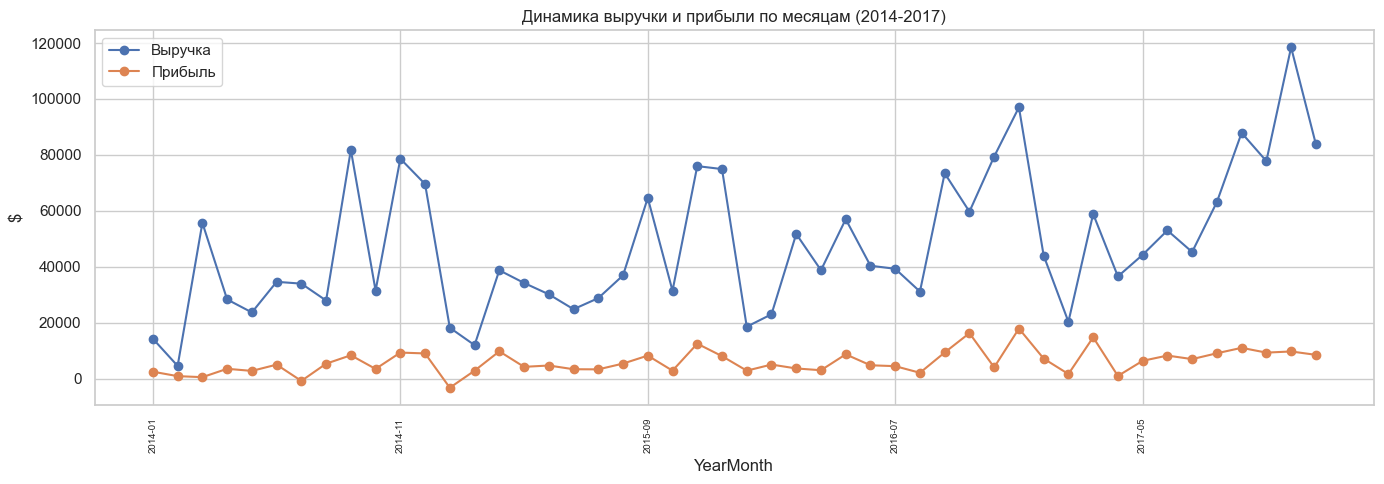

In [13]:
# Динамика выручки и прибыли по месяцам
monthly = df_clean.groupby('YearMonth').agg(Sales=('Sales','sum'), Profit=('Profit','sum'))

fig, ax = plt.subplots(figsize=(14, 5))
monthly['Sales'].plot(ax=ax, label='Выручка', marker='o')
monthly['Profit'].plot(ax=ax, label='Прибыль', marker='o')
ax.set_title('Динамика выручки и прибыли по месяцам (2014-2017)')
ax.set_ylabel('$')
ax.legend()
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()


**Наблюдение:** выручка и прибыль растут к концу каждого года (пик в ноябре-декабре — сезон
предпраздничных закупок), но рост неравномерен год к году, поэтому уверенных выводов о
долгосрочном тренде на 4 годах данных делать нельзя.

In [14]:
# Выручка и прибыль по категориям и регионам
cat_summary = df_clean.groupby('Category').agg(Sales=('Sales','sum'), Profit=('Profit','sum'))
cat_summary['Margin_%'] = round(cat_summary['Profit'] / cat_summary['Sales'] * 100, 1)
print(cat_summary)
print()
region_summary = df_clean.groupby('Region').agg(Sales=('Sales','sum'), Profit=('Profit','sum'))
region_summary['Margin_%'] = round(region_summary['Profit'] / region_summary['Sales'] * 100, 1)
print(region_summary)


                       Sales       Profit  Margin_%
Category                                           
Furniture        741999.7953   18451.2728       2.5
Office Supplies  719047.0320  122490.8008      17.0
Technology       836154.0330  145454.9481      17.4

               Sales       Profit  Margin_%
Region                                     
Central  501239.8908   39706.3625       7.9
East     678781.2400   91522.7800      13.5
South    391721.9050   46749.4303      11.9
West     725457.8245  108418.4489      14.9


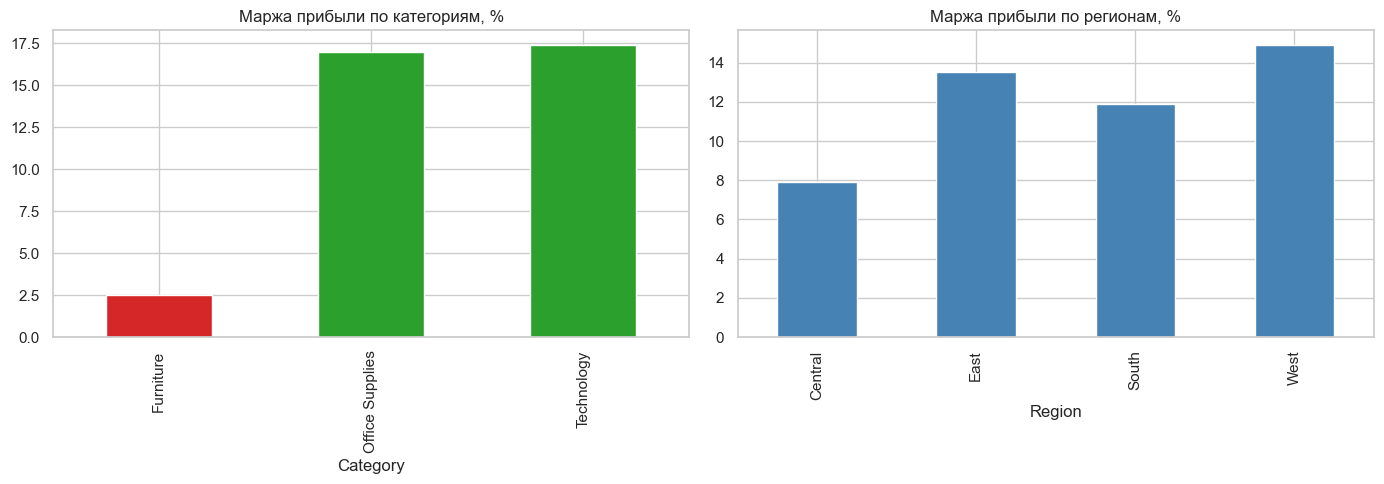

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
cat_summary['Margin_%'].plot(kind='bar', ax=ax[0], color=['#d62728' if v < 10 else '#2ca02c' for v in cat_summary['Margin_%']])
ax[0].set_title('Маржа прибыли по категориям, %')
ax[0].axhline(0, color='black', linewidth=0.8)

region_summary['Margin_%'].plot(kind='bar', ax=ax[1], color='steelblue')
ax[1].set_title('Маржа прибыли по регионам, %')
plt.tight_layout()
plt.show()


**Наблюдение:** Furniture — самая слабая категория по марже (около 2.5%) при сопоставимой с другими
категориями выручке; Technology и Office Supplies дают маржу 17%. По регионам Central заметно отстаёт
(маржа около 8% против 13-15% в остальных регионах) при не самой низкой выручке. 

DiscBin
0%         66.900292
1-20%      26.501571
21-40%    -77.864055
41-60%   -134.624160
61-80%    -98.348741
Name: Profit, dtype: float64


C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_46600\439094715.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disc_profit = df_clean.groupby('DiscBin')['Profit'].mean()


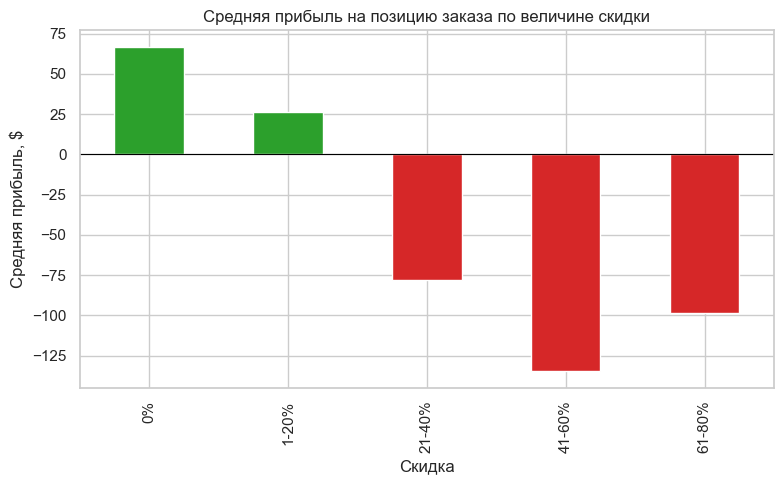

In [16]:
# Ключевая гипотеза: скидки разрушают прибыль
bins = [-0.01, 0, 0.2, 0.4, 0.6, 0.8]
labels = ['0%', '1-20%', '21-40%', '41-60%', '61-80%']
df_clean['DiscBin'] = pd.cut(df_clean['Discount'], bins, labels=labels)
disc_profit = df_clean.groupby('DiscBin')['Profit'].mean()
print(disc_profit)

plt.figure(figsize=(8, 5))
colors = ['#2ca02c' if v > 0 else '#d62728' for v in disc_profit.values]
disc_profit.plot(kind='bar', color=colors)
plt.title('Средняя прибыль на позицию заказа по величине скидки')
plt.ylabel('Средняя прибыль, $')
plt.xlabel('Скидка')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


**Ключевое наблюдение EDA:** при скидке от 0% до 20% средняя прибыль на позицию заказа положительна, а начиная с 21% скидки прибыль
становится устойчиво отрицательной (от -$78 до -$135 в зависимости от диапазона). Это подтверждается
числом наблюдений в каждой группе.

                    Sales      Profit  AvgDiscount
Sub-Category                                      
Tables        206965.5320 -17725.4811     0.261285
Bookcases     114879.9963  -3472.5560     0.211140
Supplies       46673.5380  -1189.0995     0.076842
Fasteners       3024.2800    949.5182     0.082028
Machines      189238.6310   3384.7569     0.306087
Labels         12486.3120   5546.2540     0.068681
Art            27118.7920   6527.7870     0.074874
Envelopes      16476.4020   6964.1767     0.080315
Furnishings    91705.1640  13059.1436     0.138349
Appliances    107532.1610  18138.0054     0.166524
Storage       223843.6080  21278.8264     0.074704
Chairs        328449.1030  26590.1663     0.170178
Binders       203412.7330  30221.7633     0.372292
Paper          78479.2060  34053.5693     0.074891
Accessories   167380.3180  41936.6357     0.078452
Phones        330007.0540  44515.7306     0.154556
Copiers       149528.0300  55617.8249     0.161765


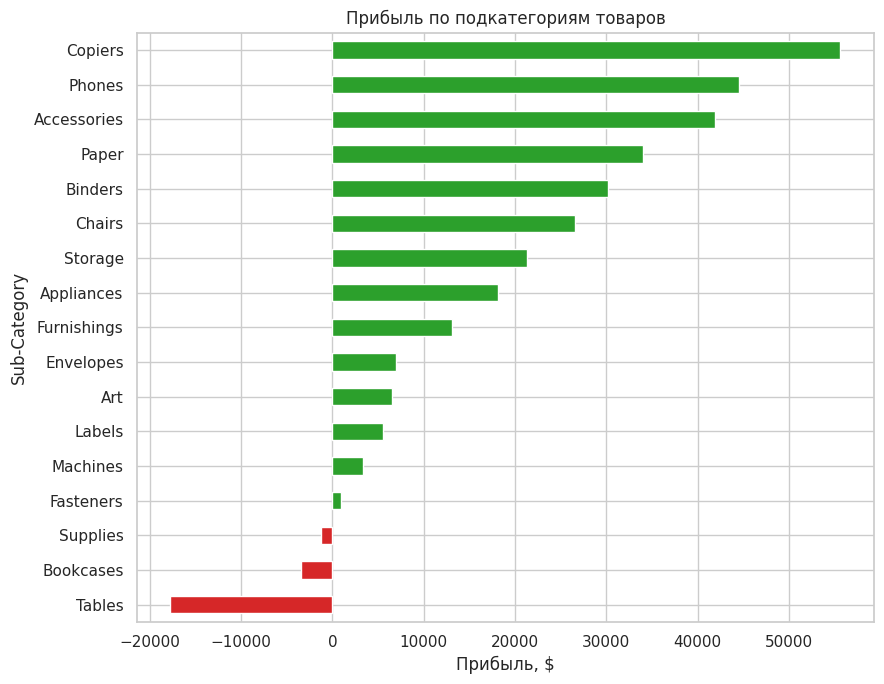

In [11]:
# Убыточные подкатегории
subcat = df_clean.groupby('Sub-Category').agg(Sales=('Sales','sum'), Profit=('Profit','sum'), AvgDiscount=('Discount','mean'))
subcat = subcat.sort_values('Profit')
print(subcat)

plt.figure(figsize=(9, 7))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in subcat['Profit']]
subcat['Profit'].plot(kind='barh', color=colors)
plt.title('Прибыль по подкатегориям товаров')
plt.xlabel('Прибыль, $')
plt.tight_layout()
plt.show()


**Наблюдение:** Tables (прибыль -$17.7 тыс. при среднем скидке 26%) и Bookcases (-$3.5 тыс. при 21%)
убыточны, несмотря на заметную выручку ($207 тыс. и $115 тыс. соответственно). Supplies тоже в минусе,
но с низкой средней скидкой (7.7%) — там причина, вероятно, не в скидках, а в изначально низкой марже
товара, здесь нужна дополнительная проверка себестоимости, которой в датасете, ксожалению нет.

## 5. ABC-анализ подкатегорий (по вкладу в выручку)

   Sub-Category      Revenue  CumRevenuePct ABC
0        Phones  330007.0540      14.365616   A
1        Chairs  328449.1030      28.663412   A
2       Storage  223843.6080      38.407602   A
3        Tables  206965.5320      47.417068   A
4       Binders  203412.7330      56.271876   A
5      Machines  189238.6310      64.509669   A
6   Accessories  167380.3180      71.795941   A
7       Copiers  149528.0300      78.305082   A
8     Bookcases  114879.9963      83.305950   B
9    Appliances  107532.1610      87.986958   B
10  Furnishings   91705.1640      91.978998   B
11        Paper   78479.2060      95.395295   C
12     Supplies   46673.5380      97.427052   C
13          Art   27118.7920      98.607567   C
14    Envelopes   16476.4020      99.324805   C
15       Labels   12486.3120      99.868349   C
16    Fasteners    3024.2800     100.000000   C


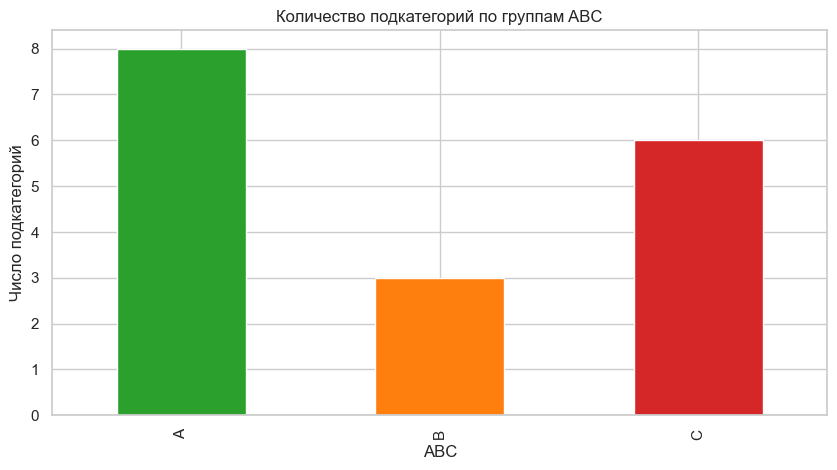

In [17]:
abc = df_clean.groupby('Sub-Category').agg(Revenue=('Sales', 'sum')).sort_values('Revenue', ascending=False).reset_index()
abc['CumRevenuePct'] = abc['Revenue'].cumsum() / abc['Revenue'].sum() * 100

def abc_group(pct):
    if pct <= 80:
        return 'A'
    elif pct <= 95:
        return 'B'
    return 'C'

abc['ABC'] = abc['CumRevenuePct'].apply(abc_group)
print(abc)

abc['ABC'].value_counts().reindex(['A','B','C']).plot(kind='bar', color=['#2ca02c','#ff7f0e','#d62728'])
plt.title('Количество подкатегорий по группам ABC')
plt.ylabel('Число подкатегорий')
plt.show()


**Вывод:** 8 из 17 подкатегорий (Phones, Chairs, Storage, Tables, Binders, Machines, Accessories,
Copiers) формируют 80% выручки (группа A). Важно, что Tables входит в группу A по выручке, но при этом
убыточна — то есть высокая выручка не гарантирует ценность для бизнеса, это должно быть отдельным
управленческим сигналом.

## 6. XYZ-анализ подкатегорий (по стабильности спроса)

X — стабильный спрос (CV ≤ 10%), Y — умеренные колебания (10-25%), Z — нестабильный спрос (>25%).

In [13]:
monthly_qty = df_clean.pivot_table(index='Sub-Category', columns='YearMonth', values='Quantity', aggfunc='sum', fill_value=0)
cv = monthly_qty.std(axis=1) / monthly_qty.mean(axis=1)

def xyz_group(c):
    if c <= 0.1:
        return 'X'
    elif c <= 0.25:
        return 'Y'
    return 'Z'

xyz = cv.reset_index()
xyz.columns = ['Sub-Category', 'CV']
xyz['XYZ'] = xyz['CV'].apply(xyz_group)
print(xyz.sort_values('CV'))
print()
print(xyz['XYZ'].value_counts())


   Sub-Category        CV XYZ
13       Phones  0.507469   Z
9   Furnishings  0.551985   Z
2           Art  0.552248   Z
3       Binders  0.560803   Z
14      Storage  0.563267   Z
12        Paper  0.580751   Z
5        Chairs  0.622882   Z
7     Envelopes  0.623490   Z
10       Labels  0.631181   Z
1    Appliances  0.642896   Z
0   Accessories  0.646969   Z
16       Tables  0.683338   Z
4     Bookcases  0.694058   Z
8     Fasteners  0.694681   Z
15     Supplies  0.720584   Z
11     Machines  1.025670   Z
6       Copiers  1.088422   Z

XYZ
Z    17
Name: count, dtype: int64


**Результат:** все 17 подкатегорий попали в группу Z (коэффициент вариации от 0.51 до 1.09).
Это особенность данных: при 4 годах наблюдений и заметной сезонности (пик в
ноябре-декабре) месячный спрос колеблется сильно у всех товаров. Вывод —
классическое XYZ-разбиение здесь не дискриминирует товары между собой, и для планирования запасов
разумнее опираться на понятную сезонность и ABC-группы, чем на XYZ-метку.

In [14]:
abc_xyz = abc.merge(xyz, on='Sub-Category')
abc_xyz['Group'] = abc_xyz['ABC'].astype(str) + abc_xyz['XYZ'].astype(str)
abc_xyz[['Sub-Category', 'Revenue', 'ABC', 'CV', 'XYZ', 'Group']].sort_values('Revenue', ascending=False)


,Sub-Category,Revenue,ABC,CV,XYZ,Group
0,Phones,330007.0540,A,0.507469,Z,AZ
1,Chairs,328449.1030,A,0.622882,Z,AZ
2,Storage,223843.6080,A,0.563267,Z,AZ
3,Tables,206965.5320,A,0.683338,Z,AZ
4,Binders,203412.7330,A,0.560803,Z,AZ
5,Machines,189238.6310,A,1.025670,Z,AZ
6,Accessories,167380.3180,A,0.646969,Z,AZ
7,Copiers,149528.0300,A,1.088422,Z,AZ
8,Bookcases,114879.9963,B,0.694058,Z,BZ
9,Appliances,107532.1610,B,0.642896,Z,BZ


## 7. RFM-анализ клиентов

In [15]:
snapshot_date = df_clean['Order Date'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('Customer ID').agg(
    Name=('Customer Name', 'first'),
    Recency=('Order Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum')
).reset_index()

rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_Sum'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

def rfm_segment(row):
    if row['RFM_Sum'] >= 13:
        return 'Champions'
    elif row['RFM_Sum'] >= 10:
        return 'Loyal'
    elif row['RFM_Sum'] >= 7:
        return 'Potential'
    elif row['RFM_Sum'] >= 5:
        return 'At Risk'
    return 'Lost'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)
print('Всего клиентов:', len(rfm))
rfm.head()


Всего клиентов: 793


,Customer ID,Name,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,RFM_Sum,Segment
0,AA-10315,Alex Avila,185,5,5563.560,2,2,5,225,9,Potential
1,AA-10375,Allen Armold,20,9,1056.390,5,5,2,552,12,Loyal
2,AA-10480,Andrew Allen,260,4,1790.512,1,1,3,113,5,At Risk
3,AA-10645,Anna Andreadi,56,6,5086.935,3,3,5,335,11,Loyal
4,AB-10015,Aaron Bergman,416,3,886.156,1,1,1,111,3,Lost


           Клиентов      Выручка  Доля_выручки_%  Доля_клиентов_%
Segment                                                          
Loyal           254  982820.7526            42.8             32.0
Champions       124  647434.9806            28.2             15.6
Potential       219  473123.0912            20.6             27.6
At Risk         116  143025.9082             6.2             14.6
Lost             80   50796.1277             2.2             10.1


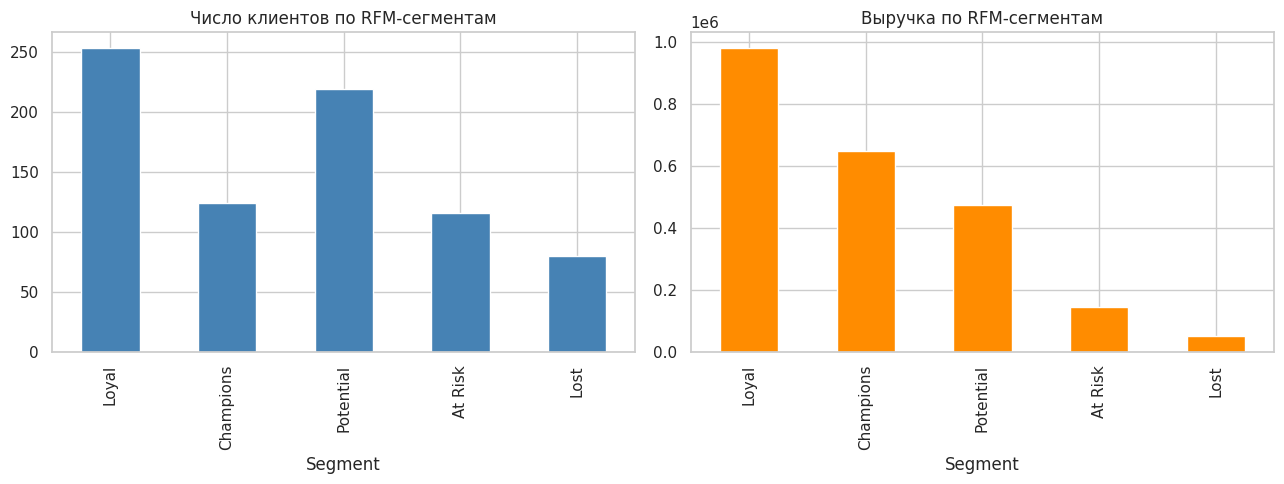

In [16]:
seg_summary = rfm.groupby('Segment').agg(Клиентов=('Customer ID', 'count'), Выручка=('Monetary', 'sum')).sort_values('Выручка', ascending=False)
seg_summary['Доля_выручки_%'] = round(seg_summary['Выручка'] / seg_summary['Выручка'].sum() * 100, 1)
seg_summary['Доля_клиентов_%'] = round(seg_summary['Клиентов'] / seg_summary['Клиентов'].sum() * 100, 1)
print(seg_summary)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
seg_summary['Клиентов'].plot(kind='bar', ax=ax[0], color='steelblue')
ax[0].set_title('Число клиентов по RFM-сегментам')
seg_summary['Выручка'].plot(kind='bar', ax=ax[1], color='darkorange')
ax[1].set_title('Выручка по RFM-сегментам')
plt.tight_layout()
plt.show()


**Вывод:** Champions (124 клиента) и Loyal (254 клиента) вместе — это 47.7% клиентской базы,
но они формируют 71% всей выручки. At Risk (116) и Lost (80 клиентов) — 24.7% клиентов дают всего 8.4%
выручки. Рекомендация: маркетинговый бюджет эффективнее удерживать на Champions/Loyal

## 8. Ответ на исследовательский вопрос

**Вопрос:** какие категории/подкатегории приносят наибольшую выручку, но теряют прибыль из-за скидок,
и какие клиентские сегменты дают основную ценность бизнесу?

**Ответ, подтверждённый расчётами выше:**

1. Общая выручка сети за 2014-2017 — $2 297 201, прибыль — $286 397 (маржа 12.5%).
2. Furniture — самая слабая по марже категория (2.5% против 17% у Technology и Office Supplies). Внутри неё убыточны Tables (-$17.7 тыс. прибыли при выручке $207 тыс.) и Bookcases (-$3.5 тыс. при выручке $115 тыс.) — обе входят в ABC-группу A по выручке, то есть это заметные товары, которые не приносят прибыли.
3. Есть чёткая связь между размером скидки и прибылью: при скидке свыше 20% средняя прибыль на позицию
   заказа становится отрицательной (от -$78 до -$135), тогда как без скидки — положительная (+$67).
   Это прямо объясняет убыточность Tables и Bookcases.
4. Region Central отстаёт по марже (7.9%) от West (14.9%) и East (13.5%) — нужно бы проверить, не завышена
   ли там скидочная политика.
5. По клиентам: 47.7% клиентской базы (Champions + Loyal) обеспечивают 71% выручки; 24.7% (At Risk + Lost) дают лишь 8.4% выручки.

## 9. Экспорт данных для BI-дашборда

In [17]:
df_clean.to_csv('cleaned_superstore.csv', index=False, encoding='utf-8-sig')
abc_xyz.to_csv('abc_xyz_analysis.csv', index=False, encoding='utf-8-sig')
rfm.to_csv('rfm_analysis.csv', index=False, encoding='utf-8-sig')
print('Готово: cleaned_superstore.csv, abc_xyz_analysis.csv, rfm_analysis.csv')


Готово: cleaned_superstore.csv, abc_xyz_analysis.csv, rfm_analysis.csv
